<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/depmap/05_mutasyon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bağımlılığın nedeni: mutasyonla ilişkilendirmek

4.4 bir soruyla bitti: bağırsak hatları CTNNB1'e neden bağımlı? Adres tablosu "hangi dokuda" sorusunu cevapladı, "neden" sorusunu açık bıraktı. Bu defterde bağımlılık skorlarını mutasyon verisiyle birleştirip nedene bir adım yaklaşıyoruz.

Bu rehber için yeni bir dosya gerekiyor: **OmicsSomaticMutationsMatrixHotspot.csv**. DepMap portalından (25Q2, All Data sekmesi) indirip 4.1'deki gibi Drive'daki proje klasörüne koyun. Dosya hücre hattı × gen boyutunda ve değerleri 0, 1 ya da 2: sıfır mutasyon yok demek, bir ve iki ise hücrede bilinen bir onkojenik hotspot mutasyonu bulunduğunu gösterir (ikisi arasındaki fark, mutasyonun hücre popülasyonundaki alel frekansıdır). "Hotspot" tanımı, mutasyonun COSMIC ve OncoKB gibi kataloglarda tekrar eden onkojenik pozisyonlarda olması demektir — yani rastgele bir değişiklik değil, işlev kazandırdığı bilinen bir değişiklik.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

KLASOR = '/content/drive/MyDrive/melisa-ile-biyoinformatik'
KOK = 'https://zenodo.org/records/22759375/files'
urllib.request.urlretrieve(f'{KOK}/depmap_ders_skorlar%20(1).csv?download=1', 'skorlar.csv')
urllib.request.urlretrieve(f'{KOK}/depmap_ders_kunye%20(1).csv?download=1', 'kunye.csv')

skor = pd.read_csv('skorlar.csv', index_col=0)
kunye = pd.read_csv('kunye.csv', index_col=0)
mut = pd.read_csv(f'{KLASOR}/OmicsSomaticMutationsMatrixHotspot.csv', index_col=0)

ortak = skor.index.intersection(mut.index)
print('skor:', skor.shape, '| mutasyon:', mut.shape, '| ortak hat:', len(ortak))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
skor: (1208, 5000) | mutasyon: (3044, 559) | ortak hat: 0


## 1. İki tabloyu hizalamak

İki dosyanın hücre hattı listeleri birebir aynı değil; ortak ModelID'lerle çalışıyoruz. Gen adları iki tabloda da `SEMBOL (EntrezID)` biçiminde olduğu için sembole göre arayan yardımcıyı her iki tablo için kullanacağız.

In [3]:
def bul(tablo, sembol):
    e = [c for c in tablo.columns if c.split(' ')[0] == sembol]
    return e[0] if e else None

def karsilastir(sembol, mut_geni=None):
    mut_geni = mut_geni or sembol
    sc, mc = bul(skor, sembol), bul(mut, mut_geni)
    if sc is None or mc is None:
        print(f'{sembol}: sütun bulunamadı'); return None
    d = pd.DataFrame({
        'skor': skor.loc[ortak, sc],
        'mutant': (mut.loc[ortak, mc] > 0).astype(int),
    }).dropna()
    m1 = d[d.mutant == 1].skor
    m0 = d[d.mutant == 0].skor
    print(f'{sembol}  (mutasyon: {mut_geni})')
    print(f'  mutant hat: {len(m1)} | medyan skor: {m1.median():.2f}')
    print(f'  yabanıl hat: {len(m0)} | medyan skor: {m0.median():.2f}')
    print(f'  fark: {m1.median() - m0.median():.2f}')
    return d

kras = karsilastir('KRAS')

KRAS  (mutasyon: KRAS)
  mutant hat: 0 | medyan skor: nan
  yabanıl hat: 0 | medyan skor: nan
  fark: nan


## 2. Onkogen bağımlılığı

Yukarıdaki çıktı, bu rehberin temel kavramını ölçüyor: **onkogen bağımlılığı**. Bir tümör hücresi sürekli açık kalmış bir onkogeni sürücü olarak kullanıyorsa, o genin ürününü kaybetmeye tahammülü yoktur — mutasyonun kendisi hücreyi o gene bağımlı hale getirir.

İki grup arasındaki fark ne kadar büyükse, bağımlılığın mutasyonla açıklanma gücü o kadar yüksektir. Aşağıda birkaç klasik onkogeni aynı hattan geçiriyoruz ve sonucu kutu grafiğiyle gösteriyoruz.

BRAF  (mutasyon: BRAF)
  mutant hat: 0 | medyan skor: nan
  yabanıl hat: 0 | medyan skor: nan
  fark: nan

PIK3CA  (mutasyon: PIK3CA)
  mutant hat: 0 | medyan skor: nan
  yabanıl hat: 0 | medyan skor: nan
  fark: nan

NRAS  (mutasyon: NRAS)
  mutant hat: 0 | medyan skor: nan
  yabanıl hat: 0 | medyan skor: nan
  fark: nan

CTNNB1  (mutasyon: CTNNB1)
  mutant hat: 0 | medyan skor: nan
  yabanıl hat: 0 | medyan skor: nan
  fark: nan

EGFR  (mutasyon: EGFR)
  mutant hat: 0 | medyan skor: nan
  yabanıl hat: 0 | medyan skor: nan
  fark: nan

KRAS  (mutasyon: KRAS)
  mutant hat: 0 | medyan skor: nan
  yabanıl hat: 0 | medyan skor: nan
  fark: nan
BRAF  (mutasyon: BRAF)
  mutant hat: 0 | medyan skor: nan
  yabanıl hat: 0 | medyan skor: nan
  fark: nan
CTNNB1  (mutasyon: CTNNB1)
  mutant hat: 0 | medyan skor: nan
  yabanıl hat: 0 | medyan skor: nan
  fark: nan


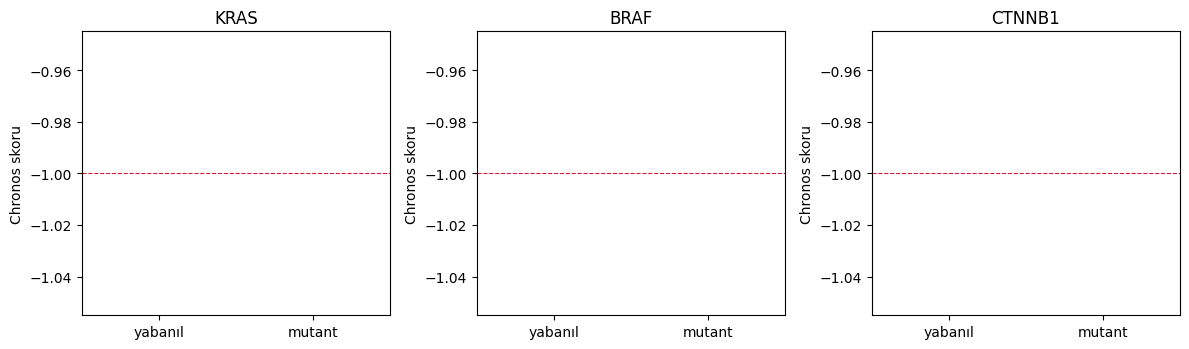

In [4]:
for g in ['BRAF', 'PIK3CA', 'NRAS', 'CTNNB1', 'EGFR']:
    karsilastir(g)
    print()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, g in zip(axes, ['KRAS', 'BRAF', 'CTNNB1']):
    d = karsilastir(g)
    if d is None: continue
    ax.boxplot([d[d.mutant == 0].skor, d[d.mutant == 1].skor],
               tick_labels=['yabanıl', 'mutant'])
    ax.axhline(-1, ls='--', lw=0.8, c='crimson')
    ax.set_title(g); ax.set_ylabel('Chronos skoru')
plt.tight_layout();

## 3. Mutasyon her şeyi açıklamıyor

Kutu grafiklerinde iki şeye birden bakın: kutuların ayrılması ve kutuların *içindeki* yayılma. Mutant grubun içinde de bağımlı olmayan hatlar, yabanıl grubun içinde de bağımlı hatlar göreceksiniz.

Bunun birkaç meşru nedeni var. Aynı yolağın başka bir üyesi mutant olabilir (KRAS yabanıl ama NRAS mutant bir hat, yine RAS yolağına bağımlı olabilir). Gen amplifiye olmuş ama mutasyonsuz olabilir. Ya da hücre o yolağı tamamen bırakıp başka bir sürücüye geçmiş olabilir. Mutasyon güçlü bir yordayıcıdır, kesin bir kural değil.

Aşağıdaki hücre bunu sayıyla gösteriyor: her gen için mutant hatların yüzde kaçı gerçekten bağımlı, ve yabanıl hatların yüzde kaçı bağımlı.

In [5]:
satir = []
for g in ['KRAS', 'BRAF', 'PIK3CA', 'NRAS', 'CTNNB1', 'EGFR']:
    sc, mc = bul(skor, g), bul(mut, g)
    if sc is None or mc is None: continue
    d = pd.DataFrame({'skor': skor.loc[ortak, sc], 'mutant': (mut.loc[ortak, mc] > 0)}).dropna()
    satir.append((
        g, int(d.mutant.sum()),
        round(100 * (d[d.mutant].skor < -1).mean(), 1),
        round(100 * (d[~d.mutant].skor < -1).mean(), 1),
    ))
print(pd.DataFrame(satir, columns=['gen', 'mutant_hat', 'mutant_bagimli_%', 'yabanil_bagimli_%']).to_string(index=False))

   gen  mutant_hat  mutant_bagimli_%  yabanil_bagimli_%
  KRAS           0               NaN                NaN
  BRAF           0               NaN                NaN
PIK3CA           0               NaN                NaN
  NRAS           0               NaN                NaN
CTNNB1           0               NaN                NaN
  EGFR           0               NaN                NaN


## 4. Ters yön: sentetik letalite

Şimdiye kadarki örnekler hep aynı genin mutasyonuna bakıyordu. Ama bağımlılığın en ilginç biçimi çapraz olanıdır: **bir gendeki kayıp, başka bir geni yaşamsal hale getirir.** Buna sentetik letalite denir ve kanser ilacı geliştirmenin en verimli fikirlerinden biridir, çünkü hedeflenen gen tümörde değil sağlıklı hücrede zararsızdır.

Ders kitabı örneği: tümör baskılayıcı VHL kaybı olan böbrek hücreli karsinom hatları, HIF2A (gen adı EPAS1) yolağına bağımlı hale gelir. Aşağıda bunu deniyoruz. Not: VHL kaybı çoğunlukla hasar verici (loss-of-function) mutasyonlarla olur, hotspot matrisi ise işlev kazandıran mutasyonlar içindir; bu yüzden aşağıdaki karşılaştırma dokuya göre yapılıyor — böbrek hatları ile diğerleri.

In [6]:
hedef = bul(skor, 'EPAS1')
if hedef:
    d = pd.DataFrame({
        'skor': skor.loc[ortak, hedef],
        'doku': kunye.loc[ortak, 'OncotreeLineage']
    }).dropna()
    bobrek = d[d.doku == 'Kidney'].skor
    digeri = d[d.doku != 'Kidney'].skor
    print(f'EPAS1 (HIF2A)')
    print(f'  böbrek hattı: {len(bobrek)} | medyan: {bobrek.median():.2f} | bağımlı oranı: %{100*(bobrek < -1).mean():.1f}')
    print(f'  diğer hatlar: {len(digeri)} | medyan: {digeri.median():.2f} | bağımlı oranı: %{100*(digeri < -1).mean():.1f}')

## Kendin dene

Üç görev. Birincisi: KRAS için mutant ve yabanıl hatların medyan skorlarını ve aradaki farkı not edin; tek cümleyle onkogen bağımlılığını kendi sözlerinizle tanımlayın. İkincisi: 3. bölümdeki tabloya bakın ve mutant-bağımlı oranının en yüksek olduğu geni bulun; yabanıl hatlarda da bağımlılık görülmesinin olası nedenlerinden birini tek cümleyle yazın. Üçüncüsü: EPAS1 sonucunu not edip tek cümleyle açıklayın — sentetik letalite, ilaç geliştirme açısından neden onkogen bağımlılığından daha değerli olabilir?